# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

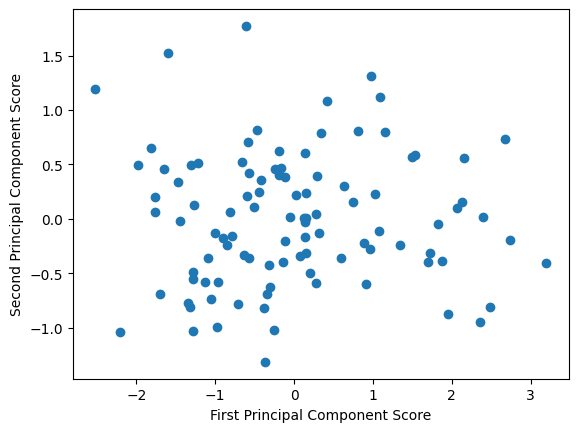

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

**Maksim Haurylik:** Scatter plot of the first two principal component scores shows that most of the variance in the data is captured by the first principal component - wide horizontal spread. It says that series_1 and series_2 contribute strongly to the first component, and series_3 contributes less.
The second principal component has less variance. 

The three outliers have low values on the first principal component and high values on the second.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

***Dataset 1: Retail Store Inventory***

In [4]:

import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_retail = pd.read_csv("retail_store_inventory.csv")
df_retail["Date"] = pd.to_datetime(df_retail["Date"])

df_retail.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


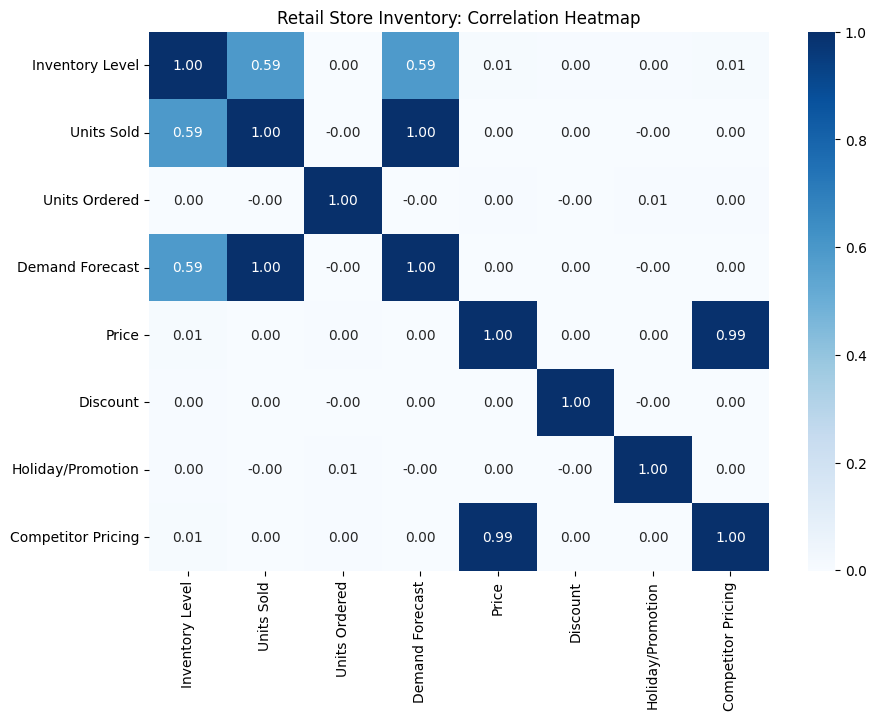

In [5]:
retail_numeric = df_retail[
    ["Inventory Level", "Units Sold", "Units Ordered",
     "Demand Forecast", "Price", "Discount",
     "Holiday/Promotion", "Competitor Pricing"]
]

plt.figure(figsize=(10, 7))
sns.heatmap(retail_numeric.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Retail Store Inventory: Correlation Heatmap")
plt.show()

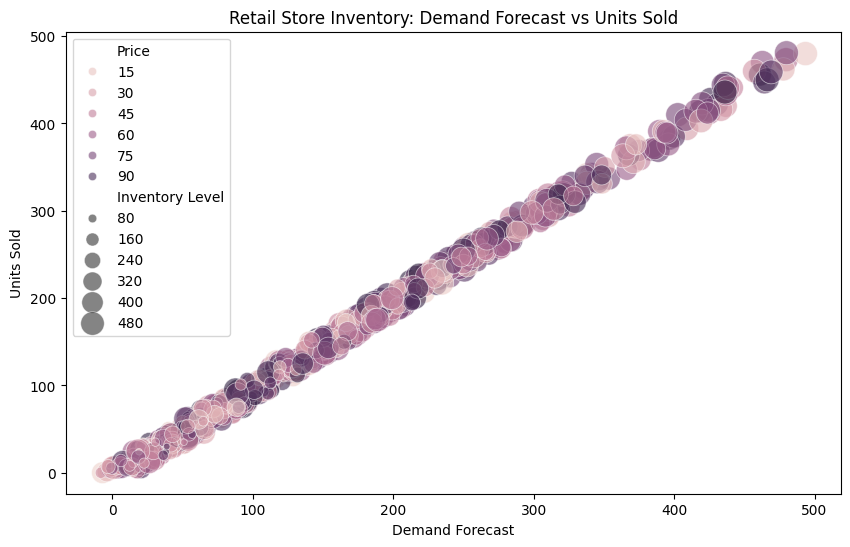

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_retail.sample(1000, random_state=42),
    x="Demand Forecast",
    y="Units Sold",
    size="Inventory Level",
    hue="Price",
    sizes=(20, 300),
    alpha=0.6
)
plt.title("Retail Store Inventory: Demand Forecast vs Units Sold")
plt.xlabel("Demand Forecast")
plt.ylabel("Units Sold")
plt.show()

In [7]:
retail_features = retail_numeric.dropna()

scaler = StandardScaler()
retail_scaled = scaler.fit_transform(retail_features)

pca_retail = PCA(n_components=retail_scaled.shape[1])
pca_retail.fit(retail_scaled)

print("Explained variance ratio:")
print(pca_retail.explained_variance_ratio_)
print("\nPrincipal component vectors:")
print(pca_retail.components_)

Explained variance ratio:
[0.30870387 0.24923615 0.12571344 0.12496361 0.12431867 0.06590864
 0.00076246 0.00039315]

Principal component vectors:
[[ 4.93319709e-01  6.15095938e-01 -4.20995195e-04  6.14804835e-01
   1.20368198e-02  3.72576389e-03  7.99386364e-04  1.21689768e-02]
 [-2.24695523e-03 -1.28740979e-02  6.30395377e-03 -1.31652135e-02
   7.06966519e-01  2.38231011e-03  3.02342197e-03  7.06965113e-01]
 [ 5.37609861e-03 -1.54438918e-03  6.89879630e-01 -1.72043577e-03
  -4.15052801e-03 -2.15902163e-01  6.90928819e-01 -4.27144287e-03]
 [ 4.10411556e-03 -4.46436779e-03  1.42845282e-01 -4.74985402e-03
  -2.92063716e-03  9.76299329e-01  1.62359967e-01 -2.49406027e-03]
 [-1.71056383e-03  1.38631356e-03  7.09655203e-01  1.37188116e-03
  -1.94759660e-03  1.33242122e-02 -7.04414342e-01 -1.36737090e-03]
 [ 8.69815785e-01 -3.47587240e-01 -3.28756304e-03 -3.49952741e-01
  -5.07436271e-03 -5.35317710e-03 -6.86750889e-03 -4.93092519e-03]
 [-1.36632737e-04  9.92527459e-04 -2.75050453e-04 -1.03

In [8]:
X_retail = df_retail[
    ["Inventory Level", "Units Ordered", "Demand Forecast",
     "Price", "Discount", "Holiday/Promotion", "Competitor Pricing"]
]
y_retail = df_retail["Units Sold"]

X_retail = X_retail.dropna()
y_retail = y_retail.loc[X_retail.index]

linreg_retail = LinearRegression()
linreg_retail.fit(X_retail, y_retail)

preds_retail = linreg_retail.predict(X_retail)

print("Retail Store Inventory Regression Results")
print("MSE:", mean_squared_error(y_retail, preds_retail))
print("R^2:", r2_score(y_retail, preds_retail))

print("\nCoefficients:")
for col, coef in zip(X_retail.columns, linreg_retail.coef_):
    print(f"{col}: {coef}")

Retail Store Inventory Regression Results
MSE: 74.35019670442827
R^2: 0.9937327425838883

Coefficients:
Inventory Level: 0.004207143906688273
Units Ordered: 0.00032793097389582915
Demand Forecast: 0.9908535618723773
Price: -0.0021919267217833933
Discount: 0.003479488508588212
Holiday/Promotion: 0.028407056782468024
Competitor Pricing: 0.003710692720691052


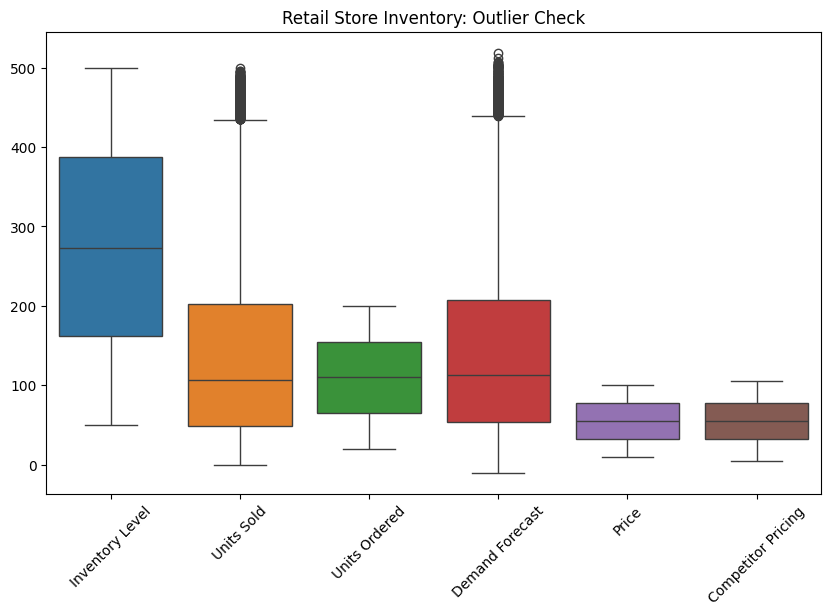

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_retail[["Inventory Level", "Units Sold", "Units Ordered", "Demand Forecast", "Price", "Competitor Pricing"]])
plt.title("Retail Store Inventory: Outlier Check")
plt.xticks(rotation=45)
plt.show()

***Dataset 2: US E-commerce Records 2020***

In [9]:
df_ecom = pd.read_csv("US  E-commerce records 2020.csv", encoding="latin1")
df_ecom["Order Date"] = pd.to_datetime(df_ecom["Order Date"], format="%d-%m-%y")

df_ecom.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


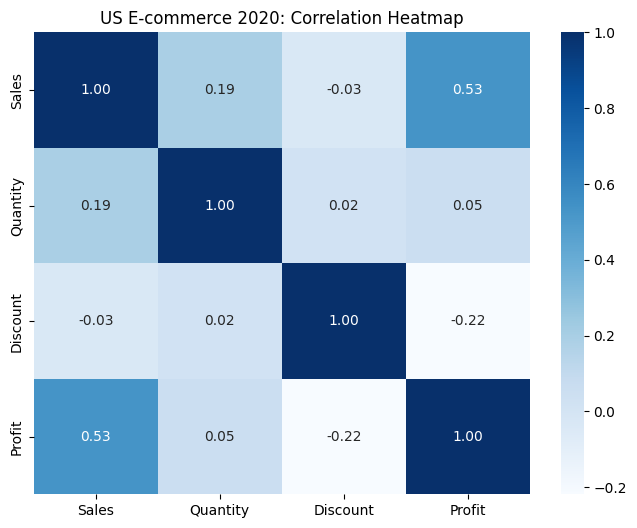

In [10]:
ecom_numeric = df_ecom[["Sales", "Quantity", "Discount", "Profit"]]

plt.figure(figsize=(8, 6))
sns.heatmap(ecom_numeric.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("US E-commerce 2020: Correlation Heatmap")
plt.show()

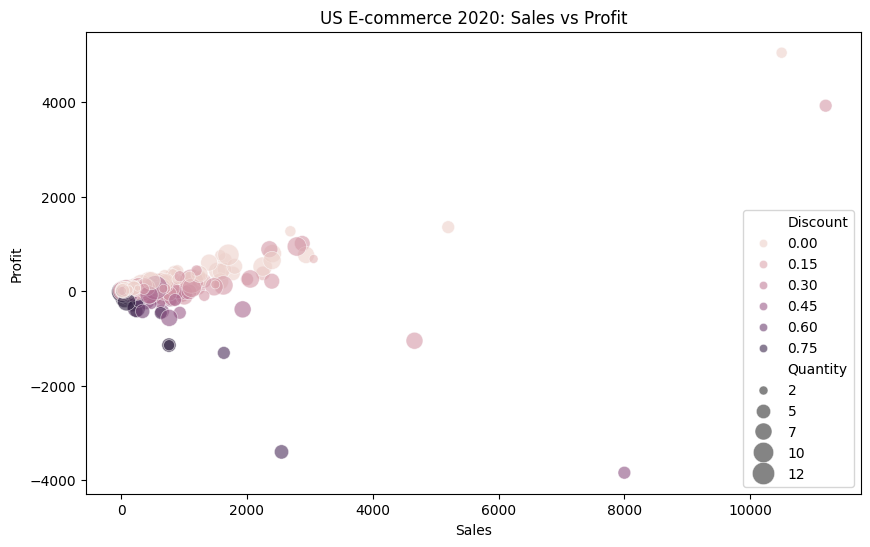

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ecom.sample(1000, random_state=42),
    x="Sales",
    y="Profit",
    size="Quantity",
    hue="Discount",
    sizes=(20, 300),
    alpha=0.6
)
plt.title("US E-commerce 2020: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [12]:
ecom_features = ecom_numeric.dropna()

scaler = StandardScaler()
ecom_scaled = scaler.fit_transform(ecom_features)

pca_ecom = PCA(n_components=ecom_scaled.shape[1])
pca_ecom.fit(ecom_scaled)

print("Explained variance ratio:")
print(pca_ecom.explained_variance_ratio_)
print("\nPrincipal component vectors:")
print(pca_ecom.components_)

Explained variance ratio:
[0.40694411 0.26571497 0.22158713 0.10575379]

Principal component vectors:
[[ 0.654085    0.24825814 -0.258952    0.66594637]
 [ 0.1980604   0.66743318  0.69684327 -0.1723789 ]
 [-0.28050098  0.6854654  -0.63273241 -0.22606656]
 [-0.67399117  0.15178285  0.2168018   0.68970636]]


In [14]:
X_ecom = df_ecom[["Sales", "Quantity", "Discount"]]
y_ecom = df_ecom["Profit"]

X_ecom = X_ecom.dropna()
y_ecom = y_ecom.loc[X_ecom.index]

linreg_ecom = LinearRegression()
linreg_ecom.fit(X_ecom, y_ecom)

preds_ecom = linreg_ecom.predict(X_ecom)

print("US E-commerce 2020 Regression Results")
print("MSE:", mean_squared_error(y_ecom, preds_ecom))
print("R^2:", r2_score(y_ecom, preds_ecom))
print("\nCoefficients:")
for col, coef in zip(X_ecom.columns, linreg_ecom.coef_):
    print(f"{col}: {coef}")

US E-commerce 2020 Regression Results
MSE: 39444.73857907259
R^2: 0.32550840749495735

Coefficients:
Sales: 0.2207338488005507
Quantity: -4.843391901736626
Discount: -232.72103667315025


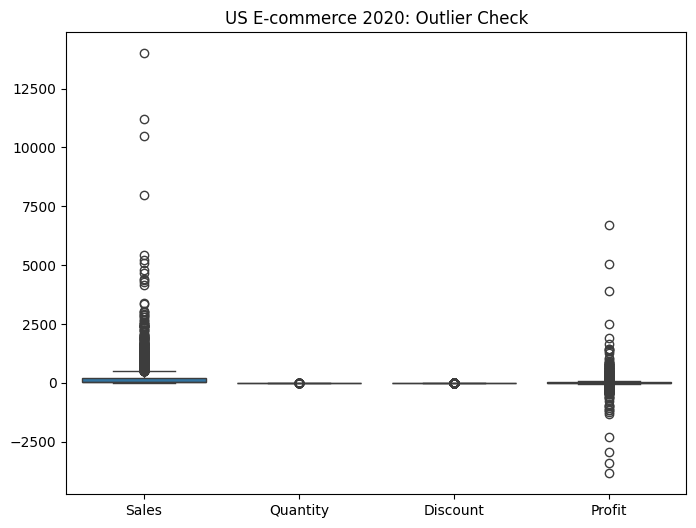

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_ecom[["Sales", "Quantity", "Discount", "Profit"]])
plt.title("US E-commerce 2020: Outlier Check")
plt.show()

***Conclusions***

1. Yes, the retail dataset can be represented using only the first principal component, because it captures the majority of the variance.
And yes, the data in the ecommerce dataset can also be represented using the projection onto the first principal component, but the effectiveness is slightly different compared to the retail dataset. In this dataset, variables such as Sales, Quantity, and Profit are related, but the relationships are less tightly coupled, and because of this the variance is more spread across multiple components.

2. For the retail dataset, the most useful variables for predicting other features will likely be Demand Forecast, Units Sold, and Inventory Level, because they are related.
For the e-commerce dataset, Sales, Discount, and Quantity are the strongest candidates for predicting Profit.

3. Retail dataset: the data looks good for prediction. E-commerce dataset: the data is usable but noisier and so may require more careful analysis

4. Each of these datasets has outliers, in ecommerce dataset they seem to be "stronger". They do not look like errors

5. Yes, as mentioned above, PCA suggests that the data can be represented using fewer dimensions, in particular using the first principal component. But for the retail dataset it is highly possible, and for the ecammerce dataset - to the lesser extend. 

6. In retail dataset, based on the correlation analysis, the most relevant features for linear regression are Demand Forecast and Inventory Level. Additionally, Price, Discount, and Competitor Pricing may also contribute.
In ecommerce dataset, Profit is influenced most strongly by Sales, while Quantity and Discount also play important roles.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

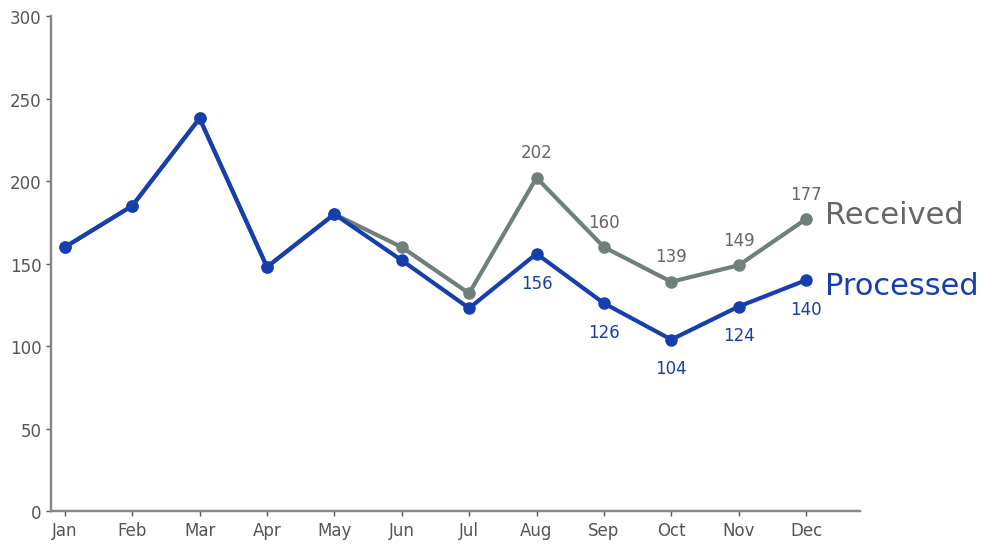

In [5]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [160, 185, 238, 148, 180, 160, 132, 202, 160, 139, 149, 177]
processed = [160, 185, 238, 148, 180, 152, 123, 156, 126, 104, 124, 140]

x = range(len(months))

plt.figure(figsize=(10, 5.6))
plt.plot(x, received, marker='o', linewidth=3, markersize=8, color='#6f7f7c')
plt.plot(x, processed, marker='o', linewidth=3, markersize=8, color='#163fae')
plt.xticks(x, months, fontsize=12)
plt.yticks(range(0, 301, 50), fontsize=12)
plt.ylim(0, 300)
plt.xlim(-0.2, 11.8)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')
ax.spines['left'].set_linewidth(1.75)
ax.spines['bottom'].set_linewidth(1.75)
ax.tick_params(axis='both', colors='#555555', width=1)

for i in [7, 8, 9, 10, 11]:
    plt.text(x[i], received[i] + 10, str(received[i]),
             color='#666666', fontsize=12, ha='center', va='bottom')

# Value labels for Processed
for i in [7, 8, 9, 10, 11]:
    plt.text(x[i], processed[i] - 12, str(processed[i]),
             color='#163fae', fontsize=12, ha='center', va='top')

plt.text(11.28, received[-1] + 3, 'Received',
         color='#666666', fontsize=22, va='center')
plt.text(11.28, processed[-1] - 3, 'Processed',
         color='#163fae', fontsize=22, va='center')

plt.grid(False)
plt.tight_layout()
plt.show()